In [30]:
import pandas as pd
df = pd.read_csv('CarPrice_Assignment.csv')

print("First 5 rows of the dataset:")
print(df.head())

print("Dataset information:")
print(df.info())

print("Statistical summary of numerical features:")
print(df.describe())

categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

First 5 rows of the dataset:
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio h

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df = pd.read_csv('CarPrice_Assignment.csv')

df_cleaned = df.drop(['car_ID', 'CarName'], axis=1)


X = df_cleaned.drop('price', axis=1)
y = df_cleaned['price']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Updated Features")
print("Numerical:", list(numerical_features))
print("Categorical:", list(categorical_features))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])


Updated Features
Numerical: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Categorical: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


In [39]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor()
}


for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', model)])
    
    pipeline.fit(X_train, y_train)
    
    print(f"{name} trained successfully.")
    models[name] = pipeline

Linear Regression trained successfully.
Ridge Regression trained successfully.
Decision Tree Regressor trained successfully.
Random Forest Regressor trained successfully.


Linear Regression
MAE: 2244.60
MSE: 10067307.11
RMSE: 3172.90
R²: 0.87



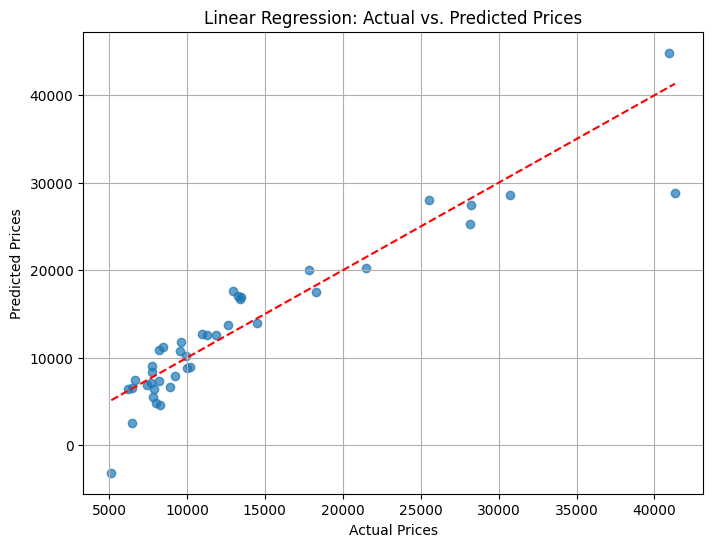

Ridge Regression
MAE: 2117.48
MSE: 10042785.71
RMSE: 3169.04
R²: 0.87



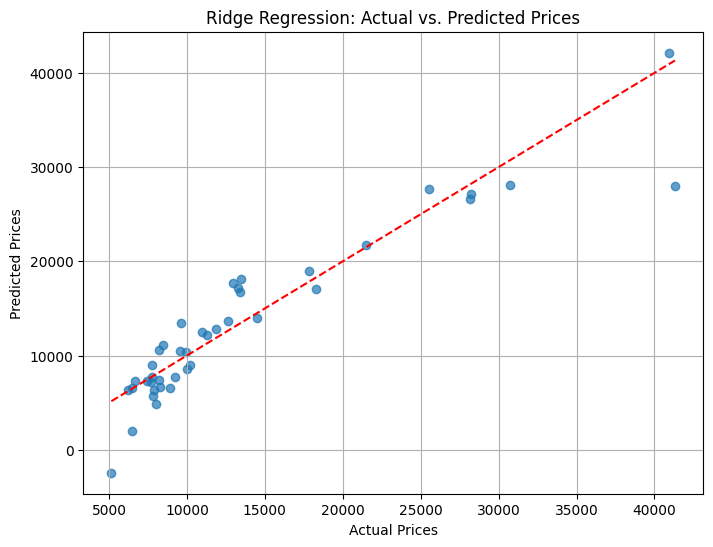

Decision Tree Regressor
MAE: 1835.11
MSE: 7476060.83
RMSE: 2734.24
R²: 0.91



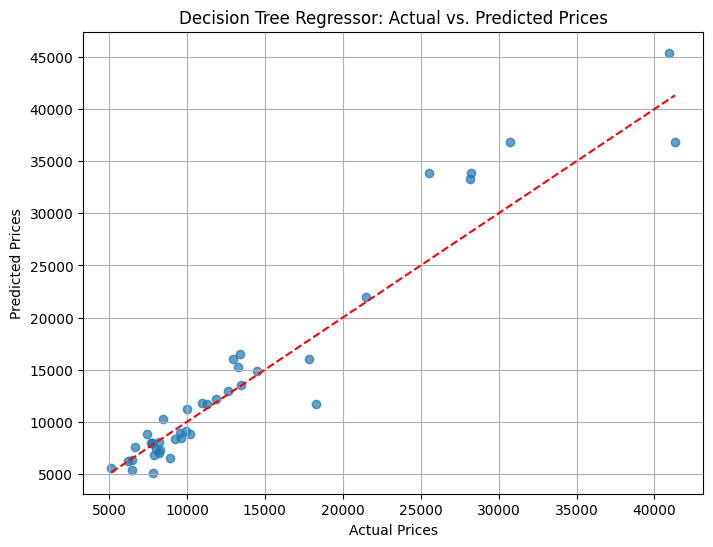

Random Forest Regressor
MAE: 1299.45
MSE: 3391032.96
RMSE: 1841.48
R²: 0.96



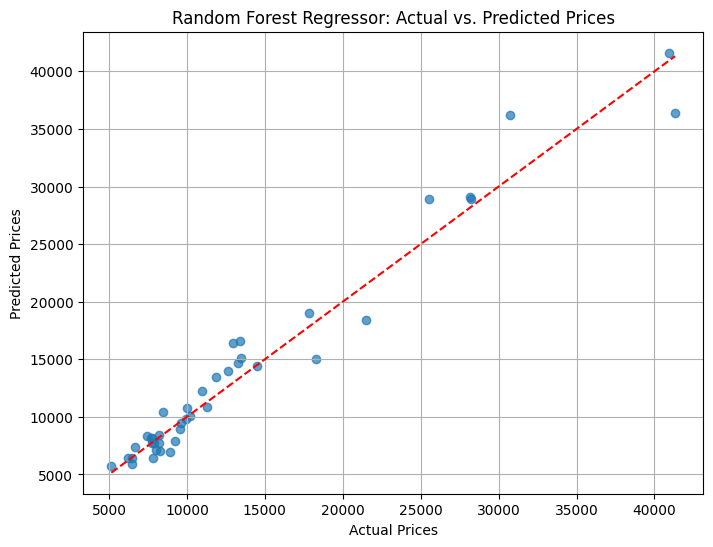

In [38]:
import numpy as np
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae = np.mean(np.abs(y_test - y_pred))
    
    mse = np.mean((y_test - y_pred)**2)
    
    rmse = np.sqrt(mse)
    
    y_cap = np.sum((y_test - y_pred)**2)
    y_dash = np.sum((y_test - np.mean(y_test))**2)
    r2 = 1 - (y_cap / y_dash)
    
    print(f"{name}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}\n")

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(f"{name}: Actual vs. Predicted Prices")
    plt.grid(True)
    plt.show()

In [42]:
import pandas as pd

new_car_data = pd.DataFrame({
    # Numerical Features
    'symboling': [3],
    'wheelbase': [98.8],
    'carlength': [175.7],
    'carwidth': [66.5],
    'carheight': [54.5],
    'curbweight': [2410],
    'enginesize': [122],
    'boreratio': [3.39],
    'stroke': [3.39],
    'compressionratio': [9.0],
    'horsepower': [111],
    'peakrpm': [5000],
    'citympg': [21],
    'highwaympg': [27],

    # Categorical Features
    'fueltype': ['gas'],
    'aspiration': ['std'],
    'doornumber': ['four'],
    'carbody': ['convertible'],
    'drivewheel': ['rwd'],
    'enginelocation': ['back'],
    'enginetype': ['ohc'],
    'cylindernumber': ['six'],
    'fuelsystem': ['mpfi']
})

predicted_price = best_model.predict(new_car_data)
print(f"Predicted price for the new car: ${predicted_price[0]:.2f}")

Predicted price for the new car: $13192.23
